# Assignment: Frequency Sweep for a Damped Harmonic Oscillator PINN

Here we investigate how a PINN performs as the oscillation frequency increases.

The damped harmonic oscillator is governed by

[x'' + 0.1x' + \omega_0^2 x = 0]

with initial conditions

[x(0)=1,\qquad x'(0)=0]

We train the PINN for different values of

[omega_0 = [1, 5, 10, 15, 20]]

and compare the learned solution against the exact analytical solution.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

## Exact Solution

For the damped harmonic oscillator,

[x'' + 0.1x' + \omega_0^2 x = 0]

the analytical solution is

[x(t)=e^{-0.05t}[cos(omega_d t)+{0.05/omega_d}sin(omega_d t)]

where

[omega_d=\sqrt{\omega_0^2-0.05^2}]

In [2]:
def exact_solution(t, omega):
    alpha = 0.05
    wd = np.sqrt(omega**2 - alpha**2)

    return np.exp(-alpha*t) * (
        np.cos(wd*t)
        + (alpha/wd)*np.sin(wd*t)
    )

## PINN Architecture

The PINN is trained by minimizing:

1. The PDE residual loss.
2. The initial condition loss.

The neural network predicts the displacement \(x(t)\).

In [3]:
class PINN(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(1,64),
            nn.Tanh(),
            nn.Linear(64,64),
            nn.Tanh(),
            nn.Linear(64,1)
        )

    def forward(self,t):
        return self.net(t)

    def loss(self,t,omega):

        x = self(t)

        dx = torch.autograd.grad(
            x.sum(),
            t,
            create_graph=True
        )[0]

        d2x = torch.autograd.grad(
            dx.sum(),
            t,
            create_graph=True
        )[0]

        pde = d2x + 0.1*dx + (omega**2)*x
        L_pde = torch.mean(pde**2)

        t0 = torch.zeros((1,1), requires_grad=True)

        x0 = self(t0)

        dx0 = torch.autograd.grad(
            x0.sum(),
            t0,
            create_graph=True
        )[0]

        L_ic = (x0-1)**2 + dx0**2

        return L_pde + 100*L_ic

## Frequency Sweep

The PINN is trained separately for each frequency value.

For every frequency we record:

- Final training loss
- Final L2 error with respect to the exact solution

In [4]:
omegas = [1,5,10,15,20]

results = []
models = {}

for omega in omegas:

    print(f"Training for ω₀ = {omega}")

    model = PINN()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1e-3
    )

    t_train = torch.linspace(
        0,
        10,
        1000
    ).reshape(-1,1)

    t_train.requires_grad_(True)

    for epoch in range(3000):

        optimizer.zero_grad()

        loss = model.loss(
            t_train,
            omega
        )

        loss.backward()
        optimizer.step()

    final_loss = loss.item()

    t_test = np.linspace(
        0,
        10,
        500
    ).reshape(-1,1)

    true = exact_solution(
        t_test,
        omega
    )

    with torch.no_grad():

        pred = model(
            torch.tensor(
                t_test,
                dtype=torch.float32
            )
        ).numpy()

    error = np.sqrt(
        np.mean(
            (pred-true)**2
        )
    )

    results.append(
        {
            "omega": omega,
            "loss": final_loss,
            "error": error
        }
    )

    models[omega] = model

Training for ω₀ = 1
Training for ω₀ = 5
Training for ω₀ = 10
Training for ω₀ = 15
Training for ω₀ = 20


## Error as a Function of Frequency

This plot shows how the prediction error changes as the oscillator frequency increases.

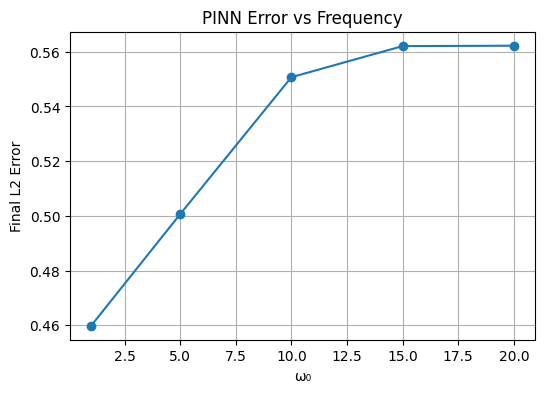

In [5]:
freqs = [r["omega"] for r in results]
errors = [r["error"] for r in results]

plt.figure(figsize=(6,4))
plt.plot(freqs, errors, marker="o")
plt.xlabel("ω₀")
plt.ylabel("Final L^2 Error")
plt.title("PINN Error vs Frequency")
plt.grid(True)
plt.show()

## Worst Performing Frequency

The frequency with the largest L^2 error is selected and compared against the analytical solution.

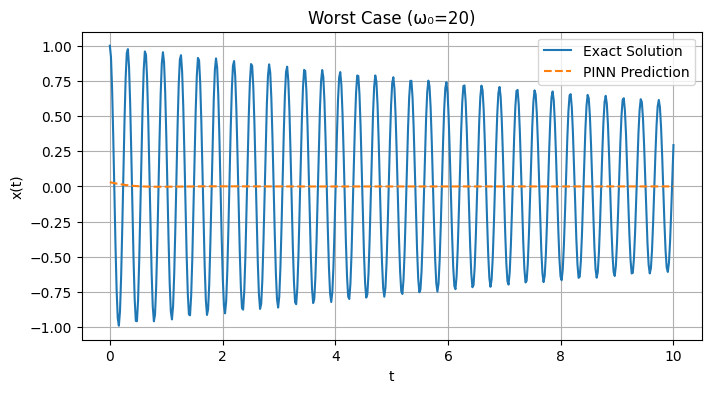

In [6]:
worst = max(
    results,
    key=lambda x:x["error"]
)

omega_worst = worst["omega"]

t = np.linspace(
    0,
    10,
    500
).reshape(-1,1)

exact = exact_solution(
    t,
    omega_worst
)

with torch.no_grad():

    pred = models[omega_worst](
        torch.tensor(
            t,
            dtype=torch.float32
        )
    ).numpy()

plt.figure(figsize=(8,4))

plt.plot(
    t,
    exact,
    label="Exact Solution"
)

plt.plot(
    t,
    pred,
    "--",
    label="PINN Prediction"
)

plt.title(
    f"Worst Case (ω₀={omega_worst})"
)

plt.xlabel("t")
plt.ylabel("x(t)")
plt.legend()
plt.grid(True)
plt.show()

# Written Reflection

## 1. What is spectral bias in neural networks, and what does your frequency sweep experiment demonstrate about it?

Spectral bias is the tendency of neural networks to learn low-frequency and smooth functions more easily than high-frequency functions. In this experiment, the PINN accurately learned the solution for smaller values of ω₀, where the oscillations are relatively slow. As ω₀ increased, the oscillations became more rapid and the prediction error increased. This demonstrates that standard PINNs struggle to capture high-frequency behavior and therefore exhibit spectral bias.

## 2. Based on what you observed, what would you try to fix the high-frequency failure?

One option is to use Fourier feature embeddings or sinusoidal activation functions (SIREN networks), which are better suited for representing oscillatory functions. Another possibility is to increase the network capacity by adding more layers or neurons. Adaptive sampling of collocation points and frequency-aware loss weighting may also help the network learn rapidly varying solutions more effectively.